# Online Retail II — RFM + K-Means Customer Segmentation

**Complete project:** Load Data → Understand → Clean → Data Visualization → RFM → Transform → Scale → Elbow Method → K-Means → Evaluation → Customer Segments → Visualization → Save Results

**Final algorithm: K-Means Clustering**


## 1. Import Required Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Load the Dataset

In [3]:
df = pd.read_csv("online_retail_II.csv")

print("Dataset Shape:", df.shape)
display(df.head())


Dataset Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 3. Understand the Dataset

In [4]:
print("Column Names:")
print(df.columns.tolist())


Column Names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [5]:
print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))


Data Types:


,Data Type
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
Price,float64
Customer ID,float64
Country,object


In [6]:
print("\nMissing Values:")
display(df.isnull().sum().to_frame("Missing Count"))


Missing Values:


,Missing Count
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [7]:
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 34335


In [8]:
print("\nStatistical Summary:")
display(df.describe(include="all").T)


Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Invoice,1067371,53628,537434,1350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,1067371,5305,85123A,5829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,1062989,5698,WHITE HANGING HEART T-LIGHT HOLDER,5918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1067371.0,NaN,NaN,NaN,9.938898,172.705794,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,1067371,47635,2010-12-06 16:57:00,1350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,1067371.0,NaN,NaN,NaN,4.649388,123.553059,-53594.36,1.25,2.1,4.15,38970.0
Customer ID,824364.0,NaN,NaN,NaN,15324.638504,1697.46445,12346.0,13975.0,15255.0,16797.0,18287.0
Country,1067371,43,United Kingdom,981330,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Data Cleaning

In [9]:
df["Invoice"] = df["Invoice"].astype(str)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

df = df.drop_duplicates().copy()

df = df.dropna(
    subset=["Customer ID", "InvoiceDate", "Quantity", "Price"]
).copy()

df = df[~df["Invoice"].str.startswith("C", na=False)].copy()

df = df[
    (df["Quantity"] > 0) &
    (df["Price"] > 0)
].copy()

df["TotalAmount"] = df["Quantity"] * df["Price"]

print("Cleaned Dataset Shape:", df.shape)
print("Number of Customers:", df["Customer ID"].nunique())
display(df.head())


Cleaned Dataset Shape: (779425, 9)
Number of Customers: 5878


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


## 5. Data Visualization

Visualize the cleaned data **before training**.

### 5.1 Quantity Distribution

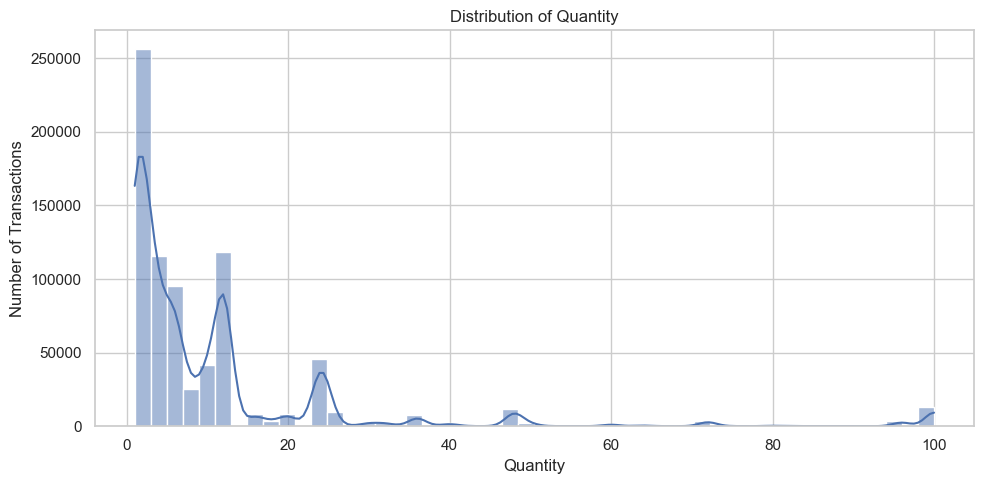

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Quantity"].clip(-100, 100), bins=50, kde=True)
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()


### 5.2 Product Price Distribution

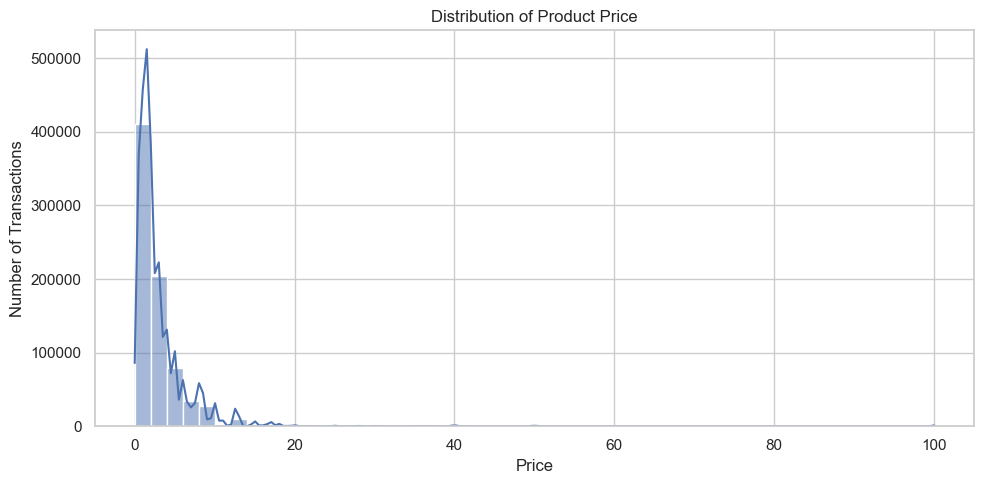

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Price"].clip(0, 100), bins=50, kde=True)
plt.title("Distribution of Product Price")
plt.xlabel("Price")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()


### 5.3 Top 10 Countries

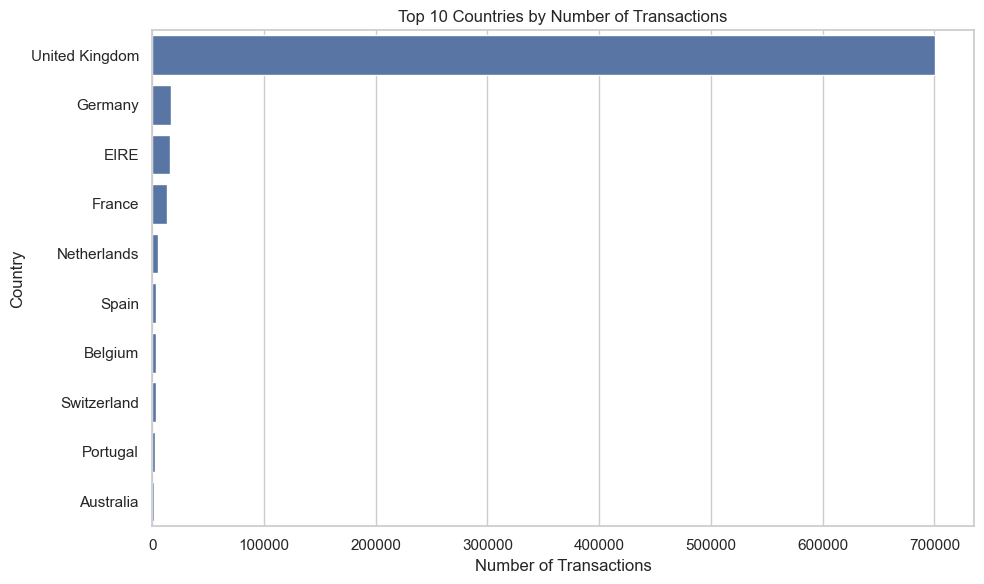

In [12]:
country_counts = df["Country"].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=country_counts.values, y=country_counts.index)
plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


### 5.4 Monthly Sales Trend

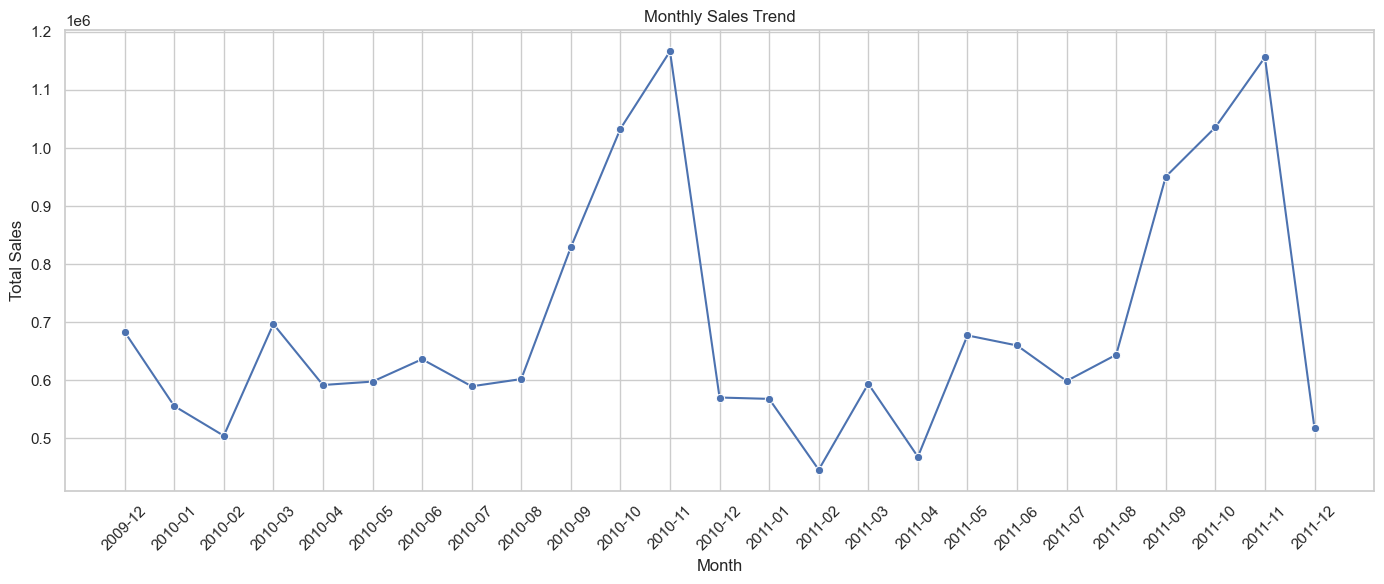

In [13]:
df["Month"] = df["InvoiceDate"].dt.to_period("M").astype(str)

monthly_sales = (
    df.groupby("Month")["TotalAmount"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_sales, x="Month", y="TotalAmount", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 5.5 Top 10 Products by Sales

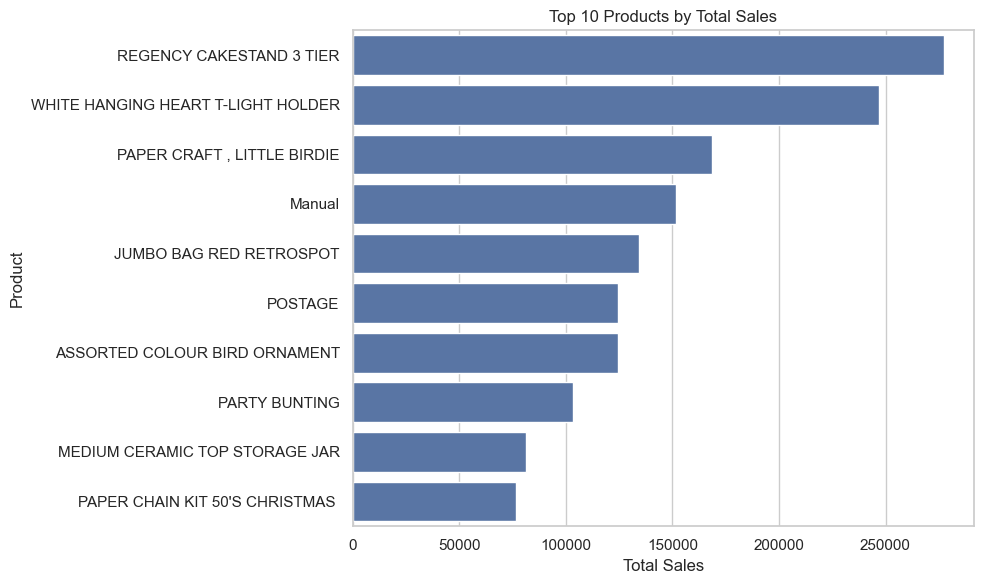

In [14]:
top_products = (
    df.groupby("Description")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Products by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


### 5.6 Quantity vs Price

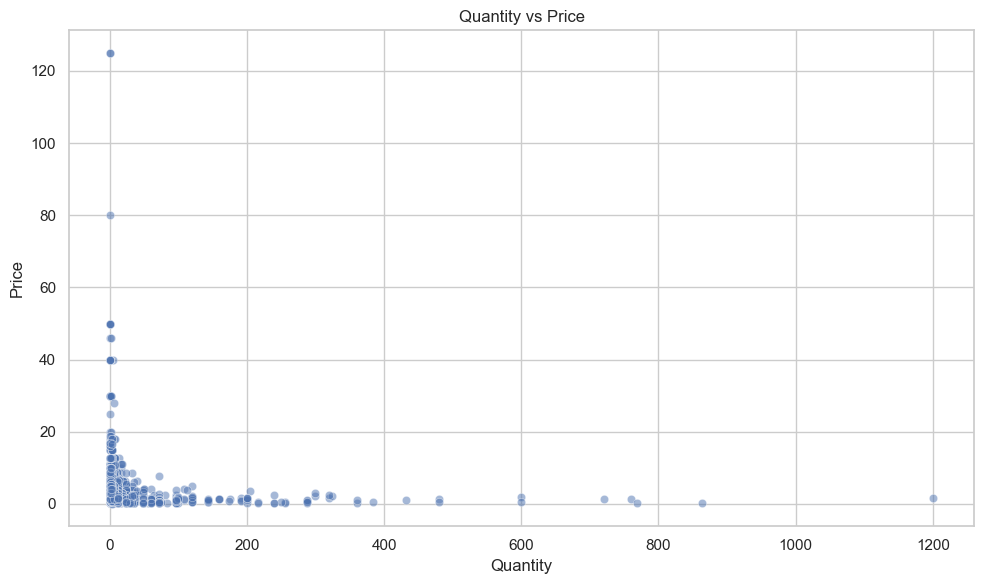

In [15]:
plot_data = df.sample(min(5000, len(df)), random_state=RANDOM_STATE)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_data, x="Quantity", y="Price", alpha=0.5)
plt.title("Quantity vs Price")
plt.xlabel("Quantity")
plt.ylabel("Price")
plt.tight_layout()
plt.show()


## 6. RFM Analysis

- **Recency:** days since the customer's last purchase
- **Frequency:** number of unique orders
- **Monetary:** total amount spent


In [18]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("Customer ID")
      .agg(
          Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
          Frequency=("Invoice", "nunique"),
          Monetary=("TotalAmount", "sum")
      )
      .reset_index()
)

print("RFM Shape:", rfm.shape)
display(rfm.head(10))


RFM Shape: (5878, 4)


,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40
5,12351.0,375,1,300.93
6,12352.0,36,10,2849.84
7,12353.0,204,2,406.76
8,12354.0,232,1,1079.40
9,12355.0,214,2,947.61


In [20]:
display(
    rfm[["Recency", "Frequency", "Monetary"]]
    .describe()
    .round(2)
)


,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00
mean,201.33,6.29,2955.90
std,209.34,13.01,14440.85
min,1.00,1.00,2.95
25%,26.00,1.00,342.28
50%,96.00,3.00,867.74
75%,380.00,7.00,2248.30
max,739.00,398.00,580987.04


## 7. RFM Visualization

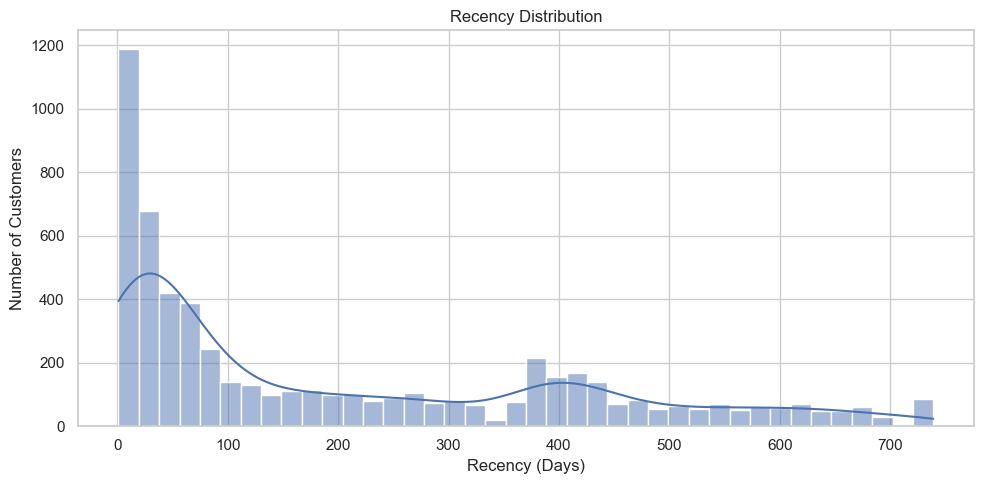

In [20]:
# Recency Visualization

plt.figure(figsize=(10, 5))

sns.histplot(
    rfm["Recency"],
    bins=40,
    kde=True
)

plt.title("Recency Distribution")
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

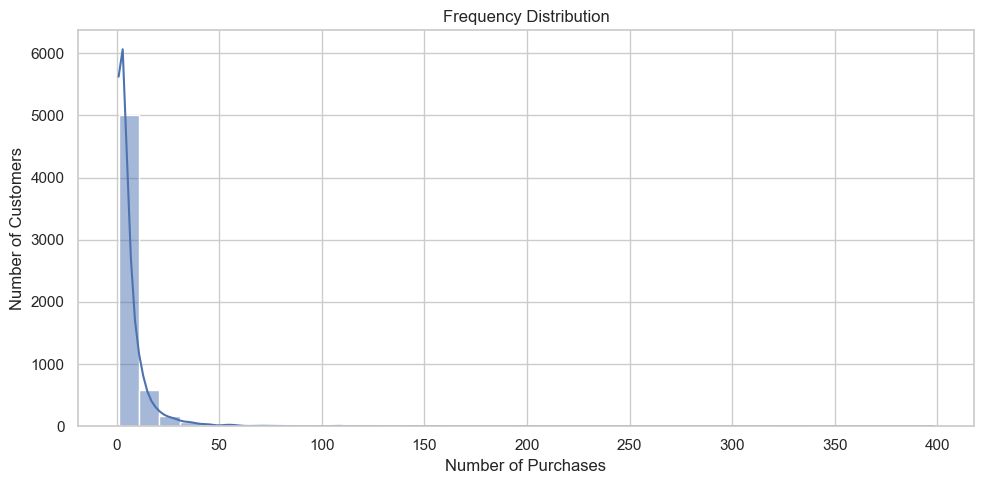

In [21]:
# Frequency Visualization

plt.figure(figsize=(10, 5))

sns.histplot(
    rfm["Frequency"],
    bins=40,
    kde=True
)

plt.title("Frequency Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

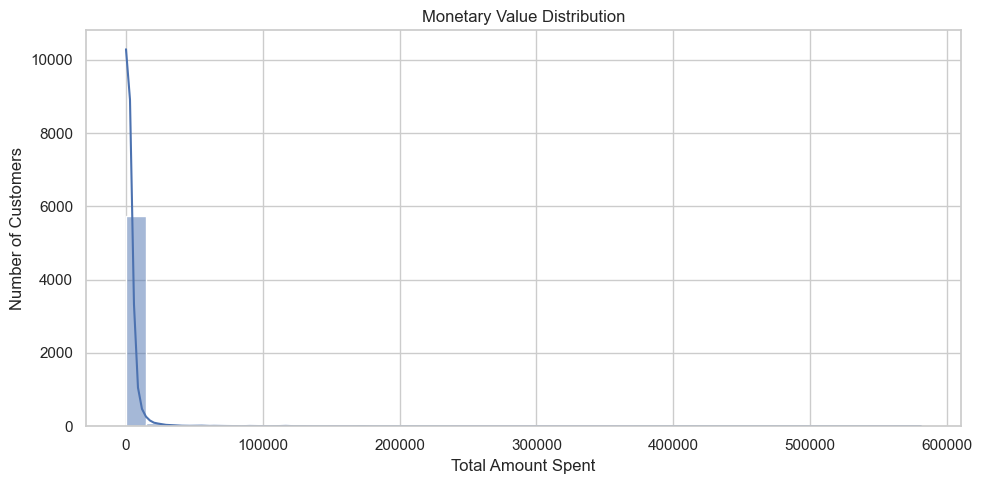

In [28]:
# Monetary Visualization

plt.figure(figsize=(10, 5))

sns.histplot(
    rfm["Monetary"],
    bins=40,
    kde=True
)

plt.title("Monetary Value Distribution")
plt.xlabel("Total Amount Spent")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

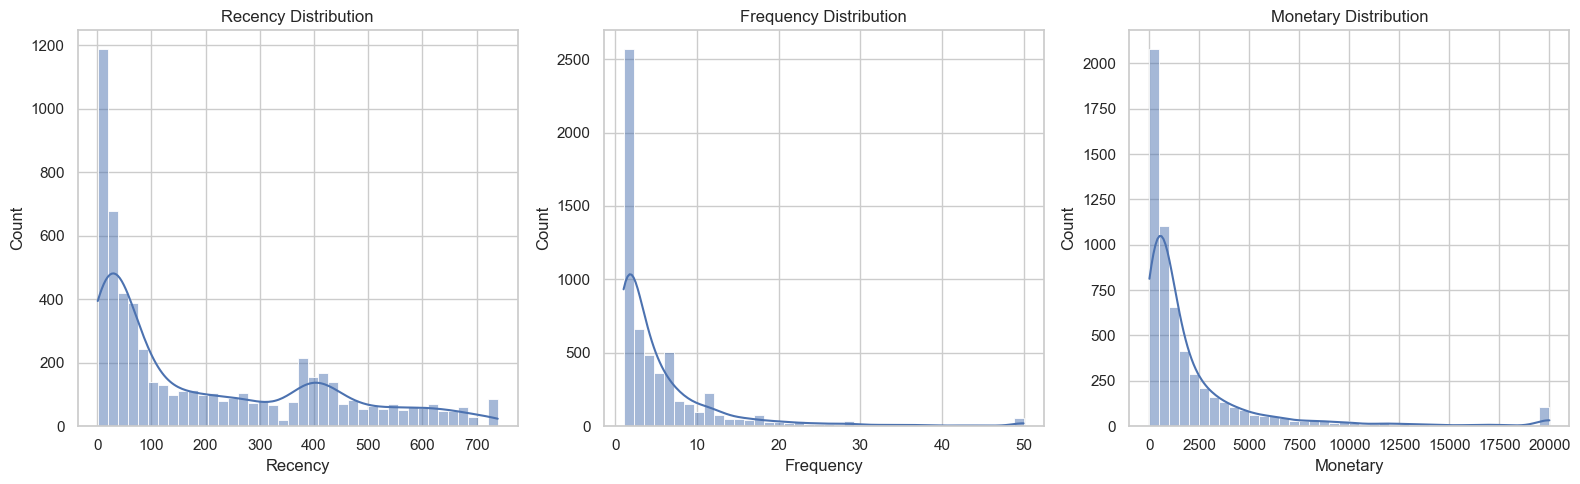

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.histplot(rfm["Recency"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"].clip(upper=50), bins=40, kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"].clip(upper=20000), bins=40, kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()


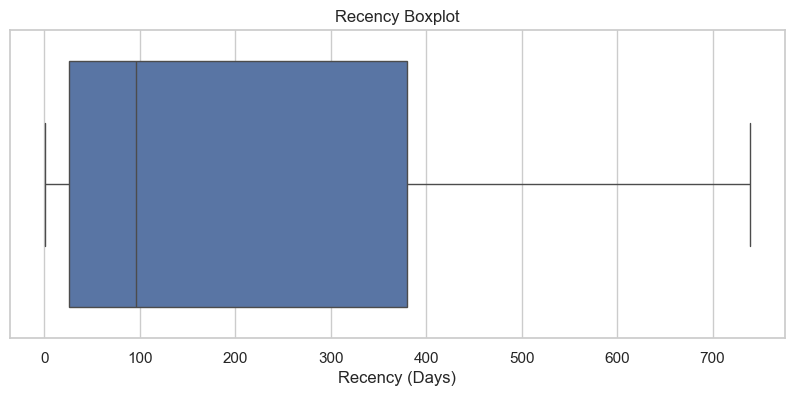

In [23]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=rfm["Recency"])

plt.title("Recency Boxplot")
plt.xlabel("Recency (Days)")

plt.show()

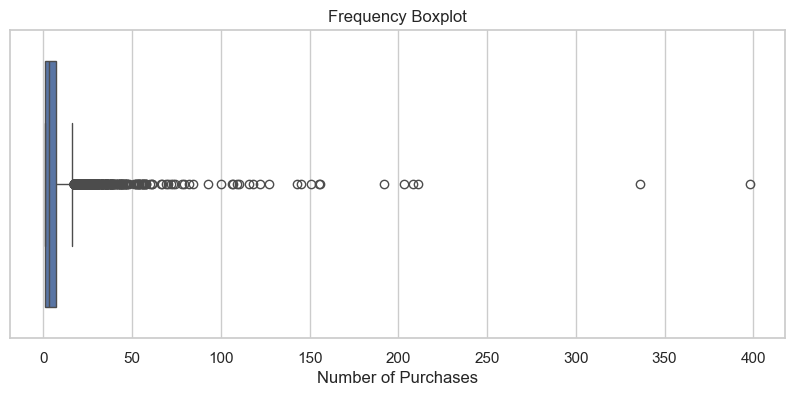

In [24]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=rfm["Frequency"])

plt.title("Frequency Boxplot")
plt.xlabel("Number of Purchases")

plt.show()

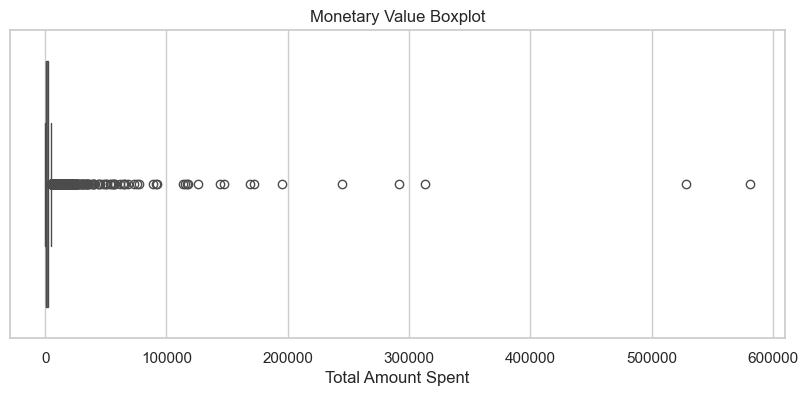

In [25]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=rfm["Monetary"])

plt.title("Monetary Value Boxplot")
plt.xlabel("Total Amount Spent")

plt.show()

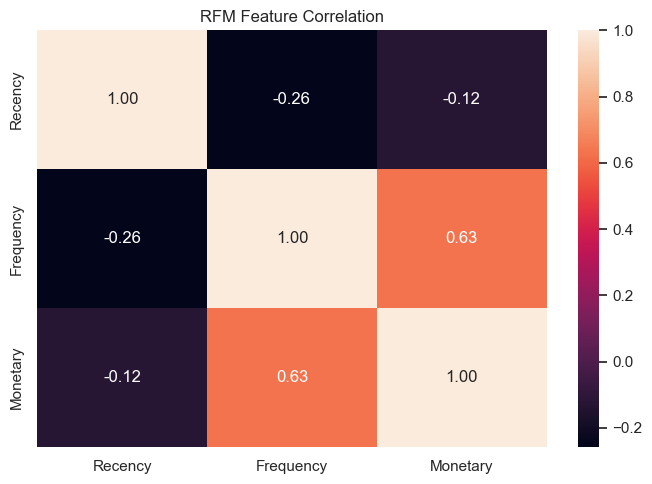

In [22]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    rfm[["Recency", "Frequency", "Monetary"]].corr(),
    annot=True,
    fmt=".2f"
)
plt.title("RFM Feature Correlation")
plt.tight_layout()
plt.show()


## 8. Log Transformation and Standard Scaling

In [23]:
rfm_features = ["Recency", "Frequency", "Monetary"]

X_log = np.log1p(rfm[rfm_features])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

print("Scaled feature shape:", X_scaled.shape)
display(pd.DataFrame(X_scaled, columns=rfm_features).head())


Scaled feature shape: (5878, 3)


,Recency,Frequency,Monetary
0,0.856701,1.254496,3.206219
1,-2.151979,0.800166,1.215993
2,-0.079138,0.299207,0.573185
3,-0.935308,0.073946,1.139846
4,0.824527,-1.058146,-0.723024


## 9. K-Means Training — Elbow Method

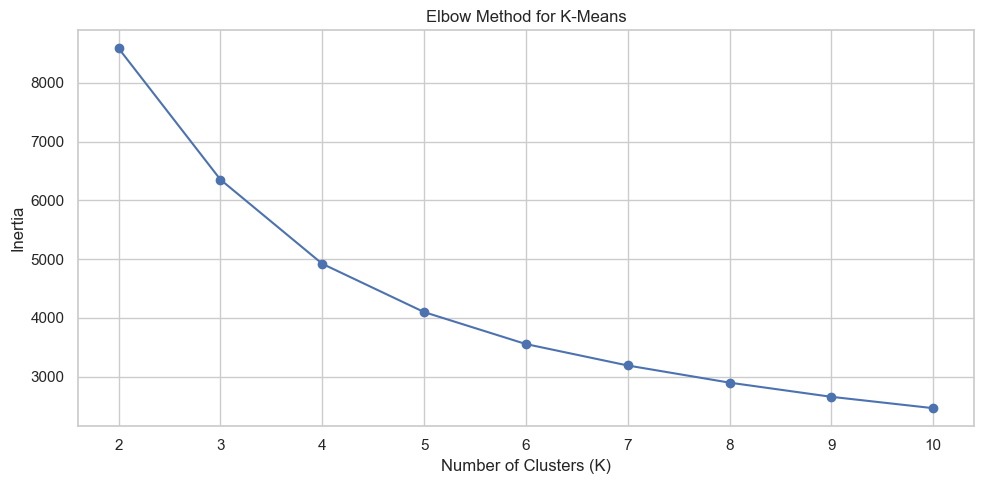

In [24]:
inertia = []
K_values = range(2, 11)

for k in K_values:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_values, inertia, marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(K_values)
plt.tight_layout()
plt.show()


In [26]:
# Final K-Means model
# K = 4

kmeans = KMeans(
    n_clusters=4,
    random_state=RANDOM_STATE,
    n_init=20
)

rfm["Cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means training completed!")
print("Number of clusters:", rfm["Cluster"].nunique())

display(
    rfm["Cluster"].value_counts().sort_index().to_frame("Customers")
)


K-Means training completed!
Number of clusters: 4


,Customers
Cluster,
0,1192
1,1972
2,1249
3,1465


## 10. Evaluate K-Means

In [27]:
silhouette = silhouette_score(X_scaled, rfm["Cluster"])

print("K-Means Silhouette Score:", round(silhouette, 4))


K-Means Silhouette Score: 0.3653


## 11. Analyze Customer Clusters

In [28]:
cluster_profile = (
    rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]]
       .agg(["count", "mean", "median"])
       .round(2)
)

display(cluster_profile)


Recency                Frequency               Monetary            \
          count    mean median     count   mean median    count      mean   
Cluster                                                                     
0          1192   27.46   17.0      1192  19.30   13.0     1192  10755.65   
1          1972  395.89  403.0      1972   1.38    1.0     1972    318.06   
2          1249   28.43   24.0      1249   3.03    3.0     1249    848.38   
3          1465  228.32  185.0      1465   5.09    5.0     1465   1957.15   

                  
          median  
Cluster           
0        4994.86  
1         273.35  
2         726.54  
3        1456.66

## 12. Create Business-Friendly Customer Segments

In [29]:
means = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

score = (
    means["Frequency"].rank(pct=True)
    + means["Monetary"].rank(pct=True)
    - means["Recency"].rank(pct=True)
)

ranked = score.sort_values(ascending=False).index.tolist()

segment_names = {
    ranked[0]: "Champions / High Value",
    ranked[1]: "Loyal Customers",
    ranked[2]: "Recent / Developing",
    ranked[3]: "At Risk / Low Value"
}

rfm["Customer_Segment"] = rfm["Cluster"].map(segment_names)

for cluster, name in segment_names.items():
    print(f"Cluster {cluster} -> {name}")


Cluster 0 -> Champions / High Value
Cluster 3 -> Loyal Customers
Cluster 2 -> Recent / Developing
Cluster 1 -> At Risk / Low Value


## 13. Final Customer Segmentation Visualization

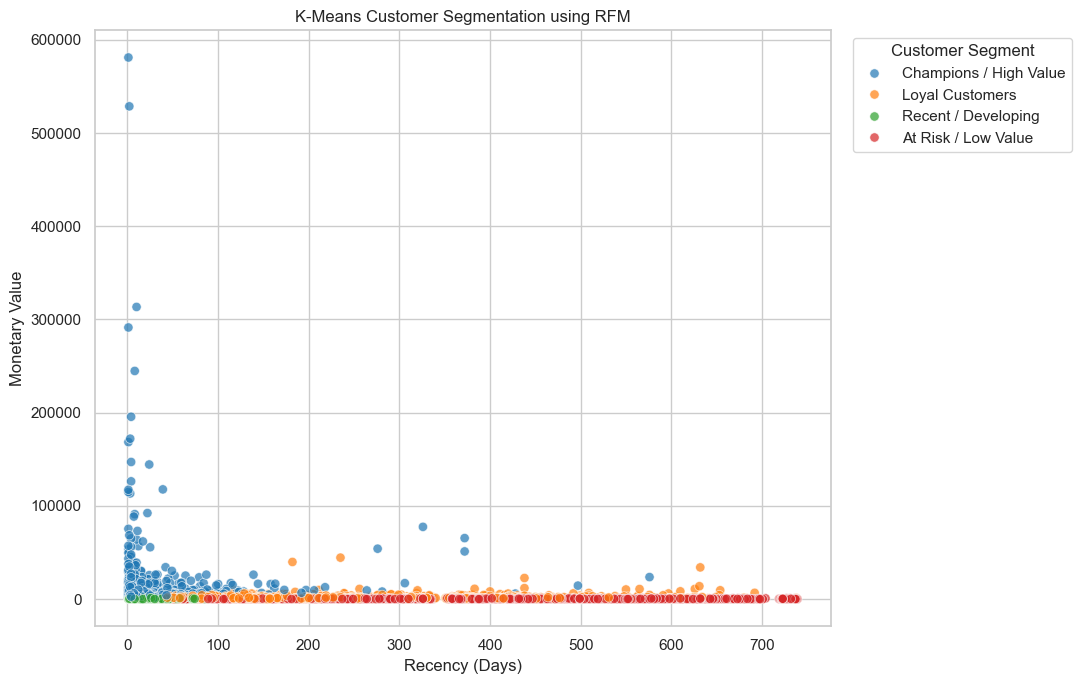

In [30]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Customer_Segment",
    palette="tab10",
    s=45,
    alpha=0.7
)

plt.title("K-Means Customer Segmentation using RFM")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")

plt.legend(
    title="Customer Segment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


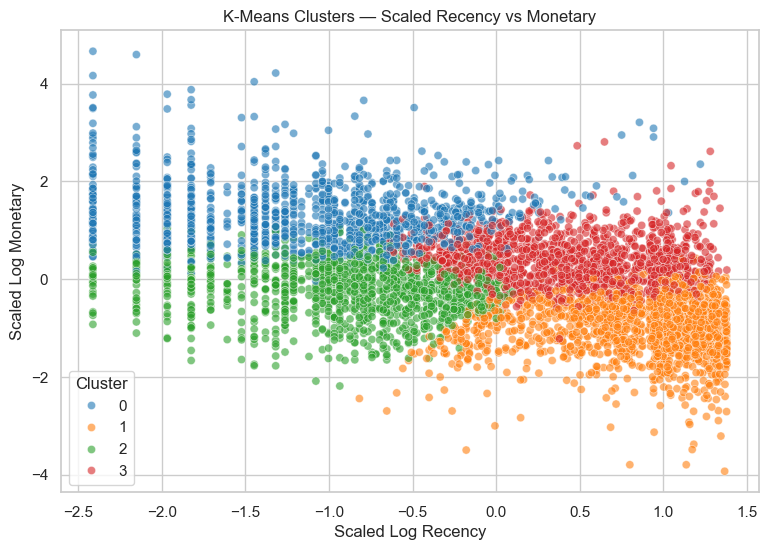

In [34]:
# 13. Final cluster visualization using scaled RFM features

plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=X_scaled[:, 0],
    y=X_scaled[:, 2],
    hue=rfm["Cluster"],
    palette="tab10",
    s=35,
    alpha=0.6
)

plt.title("K-Means Clusters — Scaled Recency vs Monetary")
plt.xlabel("Scaled Log Recency")
plt.ylabel("Scaled Log Monetary")
plt.legend(title="Cluster")
plt.show()


## 14. Final Customer Segment Summary

In [31]:
segment_summary = (
    rfm.groupby("Customer_Segment")
       .agg(
           Customers=("Customer ID", "count"),
           Average_Recency=("Recency", "mean"),
           Average_Frequency=("Frequency", "mean"),
           Average_Monetary=("Monetary", "mean")
       )
       .sort_values("Average_Monetary", ascending=False)
       .round(2)
)

display(segment_summary)


,Customers,Average_Recency,Average_Frequency,Average_Monetary
Customer_Segment,,,,
Champions / High Value,1192,27.46,19.30,10755.65
Loyal Customers,1465,228.32,5.09,1957.15
Recent / Developing,1249,28.43,3.03,848.38
At Risk / Low Value,1972,395.89,1.38,318.06


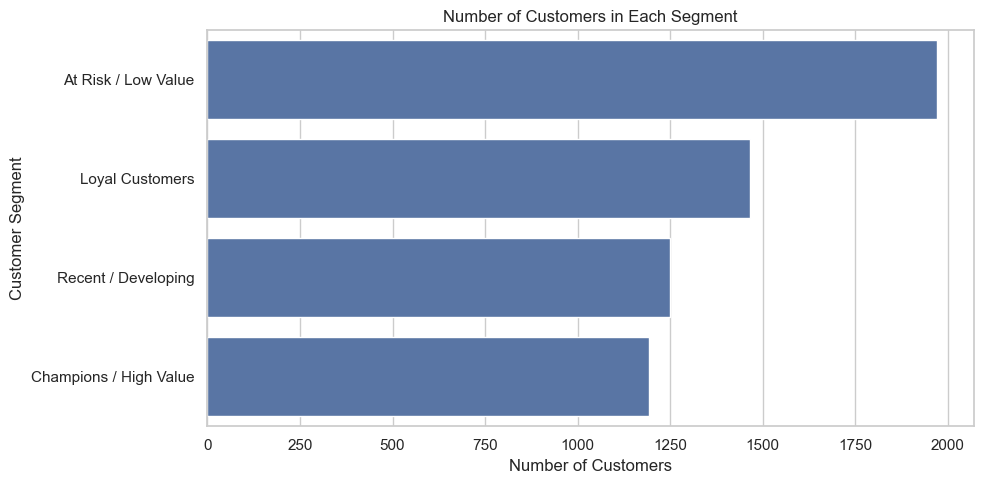

In [32]:
segment_counts = rfm["Customer_Segment"].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=segment_counts.values, y=segment_counts.index)

plt.title("Number of Customers in Each Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")
plt.tight_layout()
plt.show()


## 15. Save Final Results

In [33]:
rfm.to_csv(
    "RFM_KMeans_customer_segments.csv",
    index=False
)

print("Saved: RFM_KMeans_customer_segments.csv")


Saved: RFM_KMeans_customer_segments.csv


# Final Conclusion

The Online Retail II dataset was successfully analyzed using **RFM analysis and K-Means clustering**.

### Final workflow
**Data Cleaning → Data Visualization → RFM → Log Transformation → Standard Scaling → Elbow Method → K-Means (K=4) → Evaluation → Customer Segmentation**

The four customer segments can support:
- Customer retention
- Personalized marketing
- Loyalty programs
- High-value customer targeting
- Re-engagement campaigns

**Final model: K-Means Clustering.**
